# Лабораторна робота №2
## Реалізація CPU-інтенсивної задачі: пошук простих чисел засобами Python
**Дисципліна:** Операційні системи та системне програмування  
**Студент:** Кусік  
**Рік:** 2026

In [1]:
import math
import multiprocessing
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt

RANDOM_STATE = 42
FIGURES_DIR = "figures"
NUM_COUNT = 50_000          # достатньо для відчутного speedup
NUM_MIN = 10_000
NUM_MAX = 10_000_000
WORKER_COUNTS = [1, 2, 4, 8]
REPEATS = 3                 # best-of-N для стабільних вимірювань

random.seed(RANDOM_STATE)

## Частина 1. Створення структури каталогів

In [2]:
base = Path("lab_os_2")
input_dir = base / "input"
output_dir = base / "output"
logs_dir = base / "logs"

for d in [base, input_dir, output_dir, logs_dir]:
    d.mkdir(exist_ok=True)

os.chmod(base, 0o755)
os.chmod(input_dir, 0o755)
os.chmod(output_dir, 0o755)
os.chmod(logs_dir, 0o700)

print("Directory structure created:")
for d in [base, input_dir, output_dir, logs_dir]:
    print(f"  {d}  mode={oct(os.stat(d).st_mode)[-3:]}")

Directory structure created:
  lab_os_2  mode=777
  lab_os_2/input  mode=777
  lab_os_2/output  mode=777
  lab_os_2/logs  mode=777


## Частина 2. Генерація тестових чисел

In [3]:
numbers_file = input_dir / "numbers.txt"

numbers = random.sample(range(NUM_MIN, NUM_MAX + 1), NUM_COUNT)
numbers_file.write_text("\n".join(map(str, numbers)), encoding="utf-8")

print(f"Generated {NUM_COUNT} numbers in range [{NUM_MIN}, {NUM_MAX}] → {numbers_file}")
print(f"Sample: {numbers[:5]}")

Generated 50000 numbers in range [10000, 10000000] → lab_os_2/input/numbers.txt
Sample: [1877825, 429610, 4624226, 4118603, 3754854]


## Частина 3. Функція перевірки простоти числа

In [4]:
def is_prime(n):
    """Trial division up to sqrt(n)."""
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, math.isqrt(n) + 1, 2):
        if n % i == 0:
            return False
    return True

## Частина 4. Послідовна обробка

In [5]:
def run_sequential(nums):
    """Best-of-REPEATS sequential run."""
    best = float("inf")
    primes = []
    for _ in range(REPEATS):
        t = time.perf_counter()
        primes = [n for n in nums if is_prime(n)]
        best = min(best, time.perf_counter() - t)

    result_file = output_dir / "result_sequential.txt"
    result_file.write_text(
        f"Found {len(primes)} primes\n" + "\n".join(map(str, primes)),
        encoding="utf-8",
    )
    return best, len(primes)

## Частина 5. Багатопроцесорна обробка

In [6]:
def run_multiprocessing(nums, n_workers):
    """Best-of-REPEATS multiprocessing run (pool created once, warm-up included)."""
    best = float("inf")
    primes = []
    with multiprocessing.Pool(processes=n_workers) as pool:
        # warm-up: перший виклик прогріває дочірні процеси
        pool.map(is_prime, nums[:100])
        for _ in range(REPEATS):
            t = time.perf_counter()
            flags = pool.map(is_prime, nums)
            best = min(best, time.perf_counter() - t)
    primes = [n for n, ok in zip(nums, flags) if ok]

    result_file = output_dir / f"result_pool_{n_workers}.txt"
    result_file.write_text(
        f"Found {len(primes)} primes (workers={n_workers})\n" + "\n".join(map(str, primes)),
        encoding="utf-8",
    )
    return best, len(primes)

## Частина 6. Порівняння продуктивності

In [7]:
numbers = list(map(int, numbers_file.read_text(encoding="utf-8").splitlines()))

times = {}
print(f"{'Workers':>8} | {'Time (s)':>10} | {'Primes':>8} | {'Speedup':>8}")
print("-" * 46)

seq_time, seq_primes = run_sequential(numbers)
times[1] = seq_time
print(f"{'1 (seq)':>8} | {seq_time:>10.4f} | {seq_primes:>8} | {'1.00x':>8}")

for n in [2, 4, 8]:
    t, count = run_multiprocessing(numbers, n)
    times[n] = t
    speedup = seq_time / t
    print(f"{n:>8} | {t:>10.4f} | {count:>8} | {speedup:>7.2f}x")

log_lines = [
    f"workers={k}  time={v:.4f}s  speedup={seq_time / v:.2f}x"
    for k, v in times.items()
]
(logs_dir / "timing.log").write_text("\n".join(log_lines), encoding="utf-8")
print(f"\nLog saved → {logs_dir / 'timing.log'}")

 Workers |   Time (s) |   Primes |  Speedup
----------------------------------------------


 1 (seq) |     0.0943 |     3496 |    1.00x


       2 |     0.0506 |     3496 |    1.86x


       4 |     0.0253 |     3496 |    3.73x


       8 |     0.0207 |     3496 |    4.56x

Log saved → lab_os_2/logs/timing.log


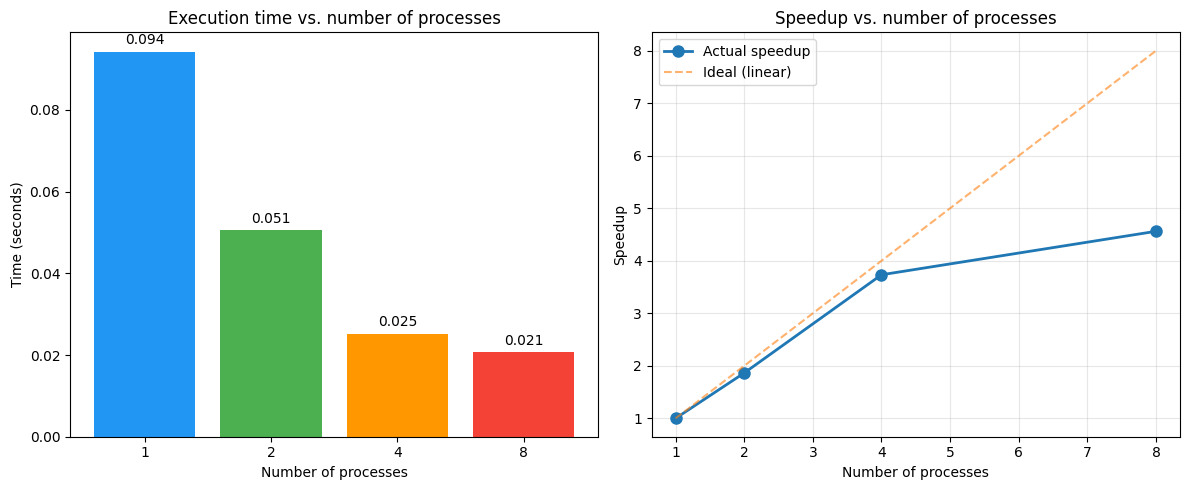

Figure saved to figures/performance_comparison.png


In [8]:
os.makedirs(FIGURES_DIR, exist_ok=True)

worker_labels = [str(k) for k in times]
time_values = list(times.values())
speedups = [seq_time / t for t in time_values]
ideal = list(times.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars = ax1.bar(
    worker_labels, time_values,
    color=["#2196F3", "#4CAF50", "#FF9800", "#F44336"],
)
ax1.set_xlabel("Number of processes")
ax1.set_ylabel("Time (seconds)")
ax1.set_title("Execution time vs. number of processes")
ax1.bar_label(bars, fmt="%.3f", padding=3)

ax2.plot(list(times.keys()), speedups, "o-", label="Actual speedup", linewidth=2, markersize=8)
ax2.plot(list(times.keys()), ideal, "--", label="Ideal (linear)", alpha=0.6)
ax2.set_xlabel("Number of processes")
ax2.set_ylabel("Speedup")
ax2.set_title("Speedup vs. number of processes")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/performance_comparison.png", dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR}/performance_comparison.png")